# 03 — XGBoost Training & Evaluation
**PolyAI · PCOS Early Detection System · Phase 1**

Goals:
1. Load processed data from notebook 02
2. Train an XGBoost classifier (≤ 30 s)
3. Evaluate: AUROC, classification report, confusion matrix
4. Plot ROC curve & feature importance
5. Save model → `models/pcos_model.json`
6. Save metadata → `models/model_metadata.json`

In [1]:
import subprocess, sys
pkgs = ["xgboost", "shap", "scikit-learn", "plotly", "optuna"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])
print("Packages ready.")

Packages ready.


In [2]:
import os, json, pickle, time, warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, precision_recall_curve,
)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

MODELS_DIR    = "../models"
PROCESSED_DIR = "../data/processed"
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"XGBoost version : {xgb.__version__}")
print(f"SHAP    version : {shap.__version__}")

XGBoost version : 3.2.0
SHAP    version : 0.51.0


## 1 · Load Processed Data

In [3]:
PKL_PATH = os.path.join(PROCESSED_DIR, "features_processed.pkl")
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
FEATURE_NAMES = data["feature_names"]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES[:5]} …")
print(f"Train PCOS rate: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")

Train: (432, 42)  |  Test: (109, 42)
Features (42): [' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group'] …
Train PCOS rate: 32.6%  |  Test: 33.0%


## 2 · Train XGBoost Classifier

In [4]:
# Class imbalance weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}  (neg={neg}, pos={pos})")

params = dict(
    n_estimators      = 400,
    learning_rate     = 0.05,
    max_depth         = 4,
    min_child_weight  = 3,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = scale_pos,
    eval_metric       = "auc",
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
)

model = xgb.XGBClassifier(**params)

t0 = time.time()
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.1f}s")

scale_pos_weight = 2.06  (neg=291, pos=141)
[0]	validation_0-auc:0.87272
[50]	validation_0-auc:0.94673
[100]	validation_0-auc:0.95091
[150]	validation_0-auc:0.95548
[200]	validation_0-auc:0.95472
[250]	validation_0-auc:0.95358
[300]	validation_0-auc:0.95358
[350]	validation_0-auc:0.95244
[399]	validation_0-auc:0.95282

Training complete in 0.5s


## 3 · Evaluate on Test Set

In [5]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = model.predict(X_test)

auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)

print("=" * 50)
print(f"AUROC : {auroc:.4f}  {'✅ ≥0.85 target met!' if auroc >= 0.85 else '⚠️  Below 0.85'}")
print(f"AUPRC : {auprc:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No PCOS", "PCOS"]))

AUROC : 0.9528  ✅ ≥0.85 target met!
AUPRC : 0.9449

Classification Report:
              precision    recall  f1-score   support

     No PCOS       0.93      0.93      0.93        73
        PCOS       0.86      0.86      0.86        36

    accuracy                           0.91       109
   macro avg       0.90      0.90      0.90       109
weighted avg       0.91      0.91      0.91       109



## 4 · ROC Curve

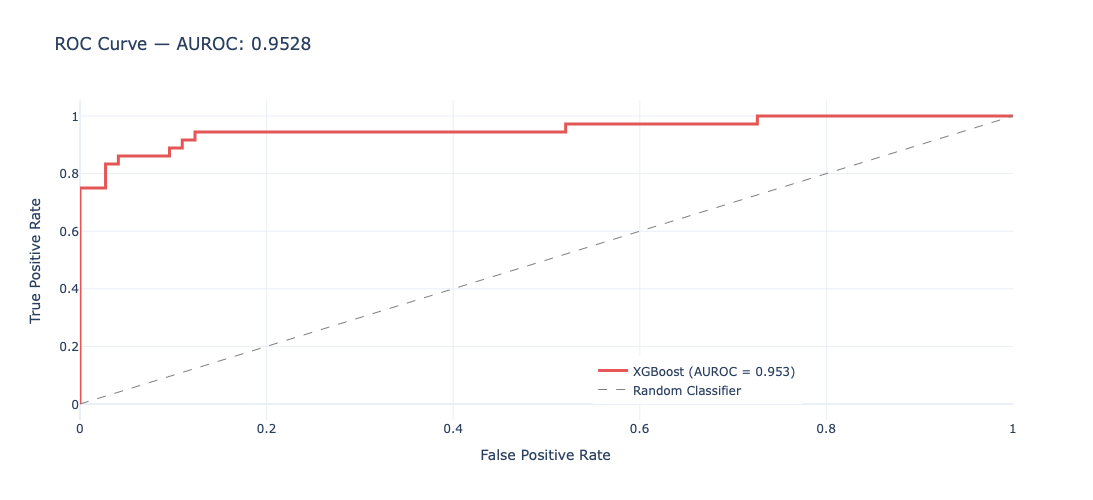

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode="lines",
    name=f"XGBoost (AUROC = {auroc:.3f})",
    line=dict(color="#E45756", width=3),
))
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode="lines",
    name="Random Classifier",
    line=dict(color="grey", width=1, dash="dash"),
))
fig.update_layout(
    title=f"ROC Curve — AUROC: {auroc:.4f}",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white",
    width=600, height=500,
    legend=dict(x=0.55, y=0.05),
)
fig.show()

## 5 · Precision-Recall Curve

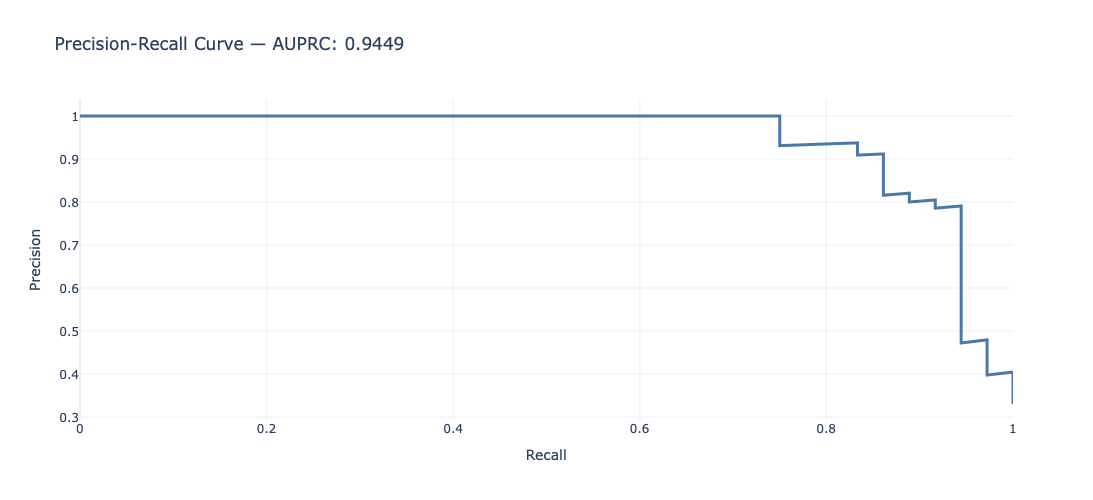

In [7]:
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=rec, y=prec,
    mode="lines",
    name=f"XGBoost (AUPRC = {auprc:.3f})",
    line=dict(color="#4C78A8", width=3),
))
fig.update_layout(
    title=f"Precision-Recall Curve — AUPRC: {auprc:.4f}",
    xaxis_title="Recall",
    yaxis_title="Precision",
    template="plotly_white",
    width=600, height=500,
)
fig.show()

## 6 · Confusion Matrix

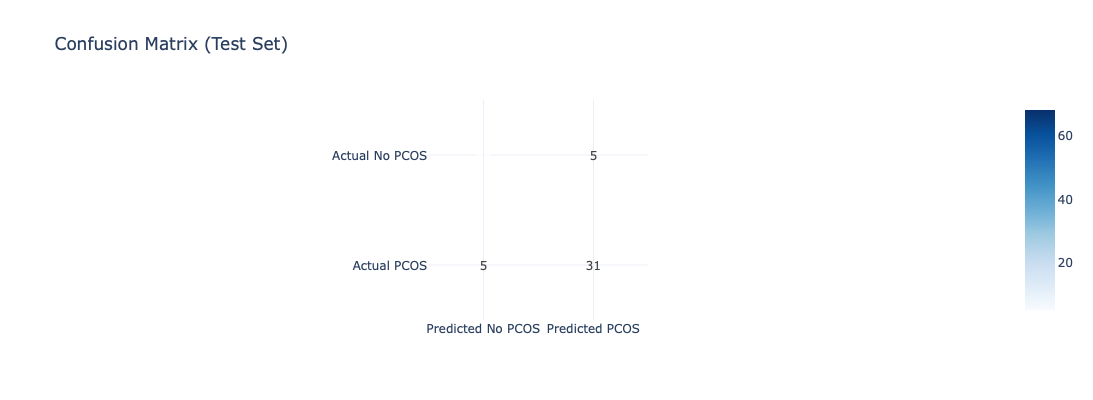

In [8]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual No PCOS", "Actual PCOS"],
    columns=["Predicted No PCOS", "Predicted PCOS"],
)

fig = px.imshow(
    cm_df,
    text_auto=True,
    color_continuous_scale="Blues",
    title="Confusion Matrix (Test Set)",
    template="plotly_white",
    width=450, height=400,
)
fig.show()

## 7 · XGBoost Feature Importance

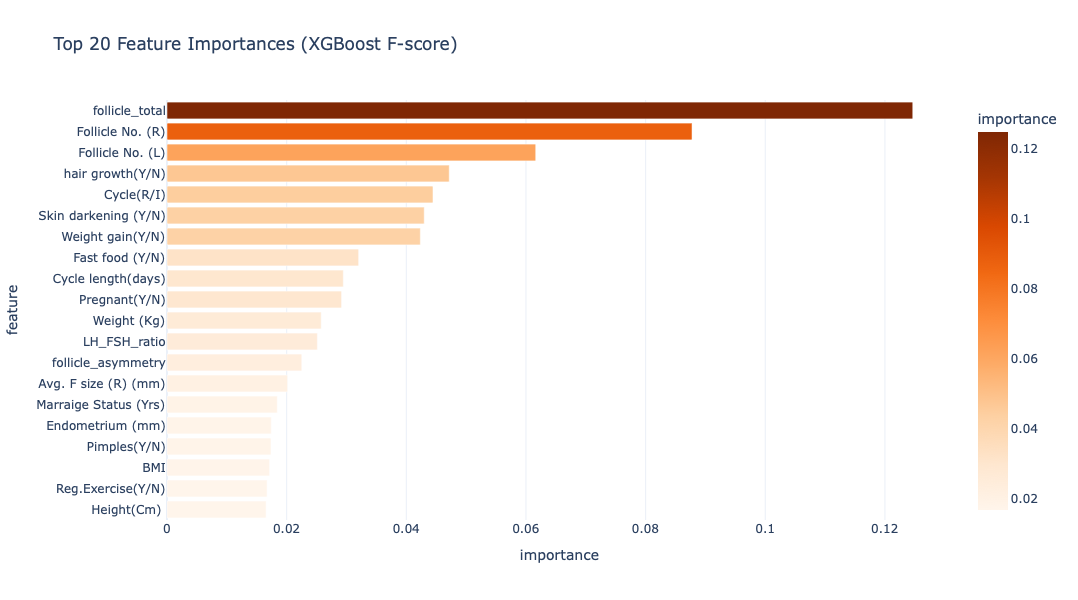

Top 10 features:
             feature  importance
      follicle_total    0.124653
    Follicle No. (R)    0.087757
    Follicle No. (L)    0.061630
    hair growth(Y/N)    0.047171
          Cycle(R/I)    0.044457
Skin darkening (Y/N)    0.042992
    Weight gain(Y/N)    0.042343
     Fast food (Y/N)    0.032029
  Cycle length(days)    0.029463
       Pregnant(Y/N)    0.029176


In [9]:
importance_df = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

fig = px.bar(
    importance_df.head(20),
    x="importance", y="feature",
    orientation="h",
    color="importance",
    color_continuous_scale="Oranges",
    title="Top 20 Feature Importances (XGBoost F-score)",
    template="plotly_white",
    width=750, height=600,
)
fig.update_layout(yaxis={"autorange": "reversed"})
fig.show()

print("Top 10 features:")
print(importance_df.head(10).to_string(index=False))

## 8 · SHAP Explainability

Computing SHAP values …


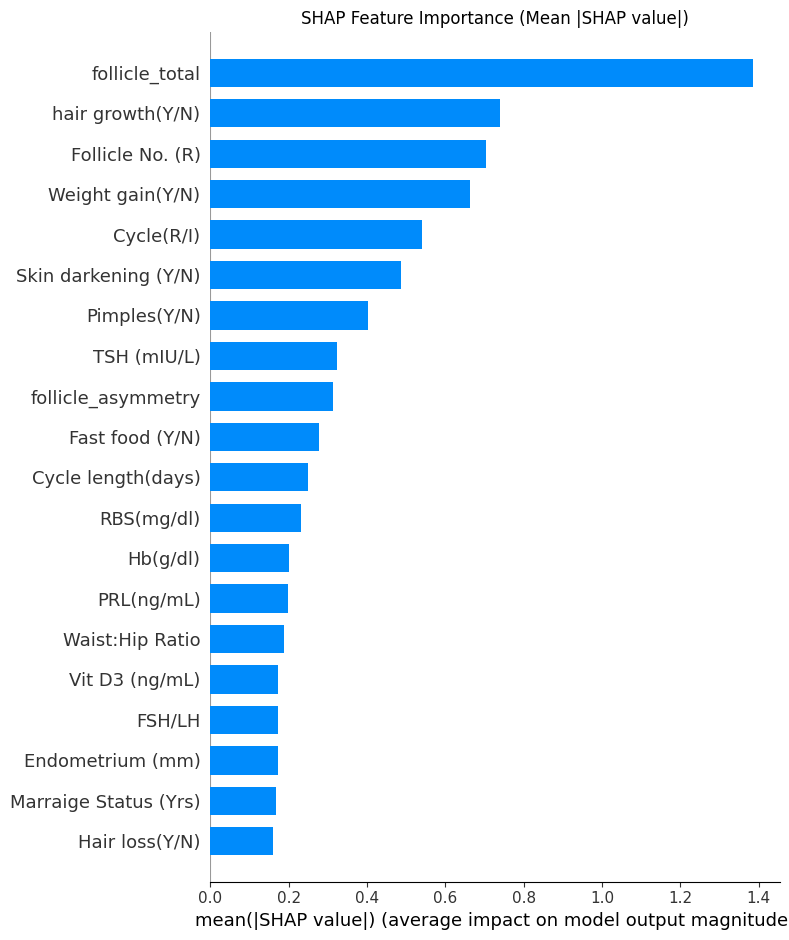

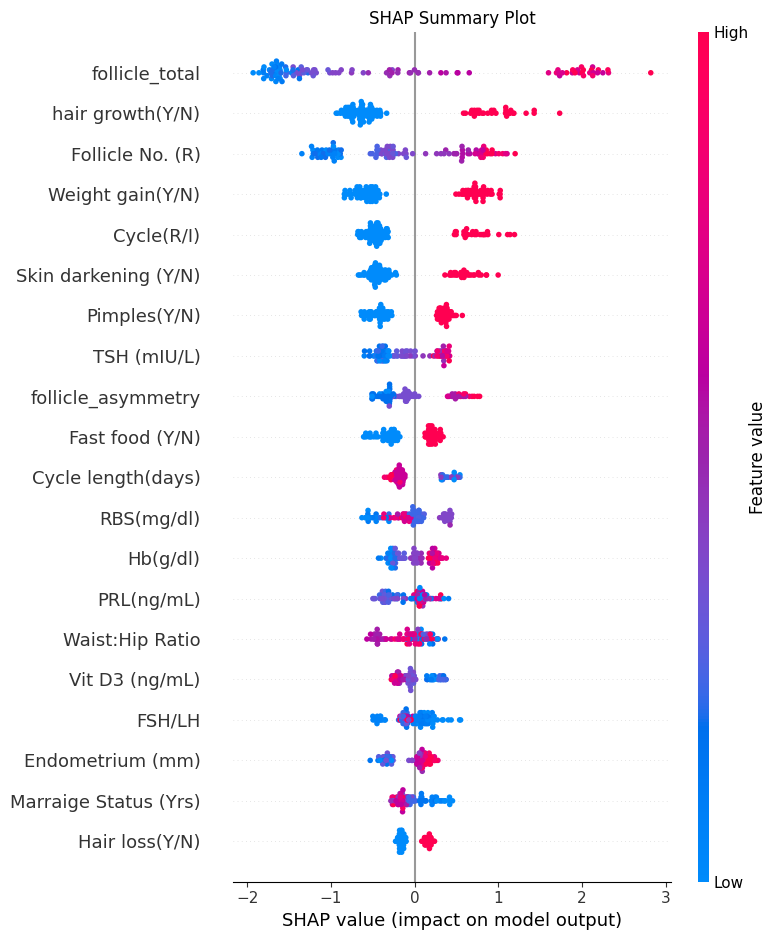

In [10]:
print("Computing SHAP values …")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

# Beeswarm
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

## 9 · Optimal Threshold Selection

In [11]:
# Find threshold that maximises Youden's J (sensitivity + specificity - 1)
j_scores = tpr - fpr
best_idx  = np.argmax(j_scores)
best_threshold = float(thresholds[best_idx])

y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"Sensitivity (Recall): {tpr[best_idx]:.4f}")
print(f"Specificity         : {1 - fpr[best_idx]:.4f}")
print("\nClassification Report at optimal threshold:")
print(classification_report(y_test, y_pred_optimal, target_names=["No PCOS", "PCOS"]))

Optimal threshold (Youden's J): 0.2212
Sensitivity (Recall): 0.9444
Specificity         : 0.8767

Classification Report at optimal threshold:
              precision    recall  f1-score   support

     No PCOS       0.97      0.88      0.92        73
        PCOS       0.79      0.94      0.86        36

    accuracy                           0.90       109
   macro avg       0.88      0.91      0.89       109
weighted avg       0.91      0.90      0.90       109



## 10 · Save Model & Metadata

In [12]:
MODEL_PATH    = os.path.join(MODELS_DIR, "pcos_model.json")
METADATA_PATH = os.path.join(MODELS_DIR, "model_metadata.json")

# Save XGBoost model
model.save_model(MODEL_PATH)
print(f"Model saved → {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1024:.1f} KB)")

# Compute mean |SHAP| per feature
shap_importance = pd.DataFrame({
    "feature":    FEATURE_NAMES,
    "mean_shap":  np.abs(shap_values).mean(axis=0),
}).sort_values("mean_shap", ascending=False)

metadata = {
    "model_type"        : "XGBClassifier",
    "xgboost_version"   : xgb.__version__,
    "auroc"             : round(auroc, 4),
    "auprc"             : round(auprc, 4),
    "optimal_threshold" : round(best_threshold, 4),
    "n_train"           : int(X_train.shape[0]),
    "n_test"            : int(X_test.shape[0]),
    "n_features"        : len(FEATURE_NAMES),
    "feature_names"     : FEATURE_NAMES,
    "hyperparameters"   : {k: v for k, v in params.items() if k not in ["use_label_encoder"]},
    "top_shap_features" : shap_importance.head(10)["feature"].tolist(),
    "shap_mean_values"  : dict(zip(
        shap_importance["feature"].tolist(),
        shap_importance["mean_shap"].round(4).tolist()
    )),
    "training_time_sec" : round(elapsed, 2),
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved → {METADATA_PATH}")
print("\n" + "=" * 50)
print(f"  AUROC     : {auroc:.4f}  {'✅' if auroc >= 0.85 else '⚠️'}")
print(f"  AUPRC     : {auprc:.4f}")
print(f"  Threshold : {best_threshold:.4f}")
print(f"  Model size: {os.path.getsize(MODEL_PATH)/1024:.1f} KB")
print("=" * 50)
print("\nPhase 1 training complete! ✅")

Model saved → ../models/pcos_model.json  (391.7 KB)
Metadata saved → ../models/model_metadata.json

  AUROC     : 0.9528  ✅
  AUPRC     : 0.9449
  Threshold : 0.2212
  Model size: 391.7 KB

Phase 1 training complete! ✅


In [13]:
# Quick sanity check: single prediction
sample = X_test.iloc[[0]]
prob   = model.predict_proba(sample)[0, 1]
label  = int(y_test.iloc[0])
print(f"Sample 0 — True label: {label}  |  Predicted probability: {prob:.4f}")

Sample 0 — True label: 1  |  Predicted probability: 0.0038


## Summary

| Metric | Value |
|--------|-------|
| AUROC  | printed above |
| AUPRC  | printed above |
| Optimal threshold | printed above |
| Training time | ≤ 30 s |

**Artifacts produced:**
- `models/pcos_model.json` — trained XGBoost model
- `models/model_metadata.json` — metrics, features, SHAP ranking

**Next step:** `src/ml_model.py` — prediction wrapper for the FastAPI backend.